In [12]:
df.columns.tolist()

['Time clock',
 ' I.1.Date of the investigation',
 ' I.2.Questionnaire code',
 ' I.3.Name of the FOSA',
 ' I.4.Location of the FOSA',
 ' I.5.Health district',
 ' I.6.Health area',
 ' I.7.Category of the FOSA',
 ' I.8.Status of the FOSA',
 ' I.9. Qualification of the FOSA manager',
 ' I.10. Gender of the FOSA manager',
 ' I.11. Telephone contact of the FOSA manager',
 ' II.1 Qualification of the respondent',
 ' II.2.Sex of the respondent',
 ' II.3.Age of the respondent in years',
 ' II.4.Number of years of practice',
 ' II.5. Telephone contact of the respondent',
 ' III.1.StaffGeneral doctorsnon-specialists',
 ' III.1.StaffDoctorsSpecialists',
 ' III.1.StaffOther clinicians',
 ' III.1.StaffNursing professionals',
 ' III.1.StaffObstetrical care professionals',
 ' III.1.Pharmacists staff',
 ' III.1.Laboratory technician staff',
 ' III.1.StaffCommunityHealthWorkers',
 'IV.1. Excluding delivery tables and workbenches',
 ' IV.2.On all observation hospitalization beds',
 ' V.1.CommunicationFu

In [15]:
for col in df.columns:
    print(repr(col))


'Time clock'
' I.1.Date of the investigation'
' I.2.Questionnaire code'
' I.3.Name of the FOSA'
' I.4.Location of the FOSA'
' I.5.Health district'
' I.6.Health area'
' I.7.Category of the FOSA'
' I.8.Status of the FOSA'
' I.9. Qualification of the FOSA manager'
' I.10. Gender of the FOSA manager'
' I.11. Telephone contact of the FOSA manager'
' II.1 Qualification of the respondent'
' II.2.Sex of the respondent'
' II.3.Age of the respondent in years'
' II.4.Number of years of practice'
' II.5. Telephone contact of the respondent'
' III.1.StaffGeneral doctorsnon-specialists'
' III.1.StaffDoctorsSpecialists'
' III.1.StaffOther clinicians'
' III.1.StaffNursing professionals'
' III.1.StaffObstetrical care professionals'
' III.1.Pharmacists staff'
' III.1.Laboratory technician staff'
' III.1.StaffCommunityHealthWorkers'
'IV.1. Excluding delivery tables and workbenches'
' IV.2.On all observation hospitalization beds'
' V.1.CommunicationFunctional fixed telephone line'
' V.1.Communicationmobil

In [16]:
df.columns = (
    df.columns
      .astype(str)
      .str.replace("\xa0", " ", regex=False)  # remove non-breaking spaces
      .str.replace("\n", " ", regex=False)
      .str.strip()
)


In [17]:
df[["Operational Capacity"]].head(10)

,Operational Capacity
0,<80
1,>=80
2,>=80
3,>=80
4,>=80
5,>=80
6,>=80
7,<80
8,<80
9,<80


In [26]:
[c for c in df.columns if "operational" in c.lower()]


[' FOSAOPERATIONAL', ' Operational Capacity']

In [25]:
df[["Operational Capacity"]].dytpe

KeyError: "None of [Index(['Operational Capacity'], dtype='object')] are in the [columns]"

In [24]:
df["Operational Capacity"].dtype


KeyError: 'Operational Capacity'

In [23]:
df["y"] = (df["Operational Capacity"] >= 80).astype(int)


KeyError: 'Operational Capacity'

In [22]:
df["y"] = (
    df["Operational Capacity"]
    .astype(str)
    .str.replace("\u2265", ">=", regex=False)  # replace ≥ with >=
    .str.replace(" ", "", regex=False)         # remove spaces
    .str.contains(r">=80", regex=True)
    .astype(int)
)


KeyError: 'Operational Capacity'

In [3]:
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace("\xa0", " ", regex=False)
    .str.replace("\n", " ", regex=False)
)


In [20]:
KEYWORDS = {
    "health_district": ["health district"],
    "category_fosa": ["category_fosa", "category fosa"],
    "status_fosa": ["status_fosa", "status fosa"],
    "gender_fosa_manager": ["gender_fosa_manager", "gender of the fosa manager"],
    "qualification_fosa_manager": ["qualification_fosa_manager", "qualification of the fosa manager"],
    "qualification_respondent": ["qualification_respondent", "qualification respondent"],
    "gender_respondent": ["sex_respondent", "gender_respondent"],
    "childbirth_services": ["childbirth services"],
    "pmtct_services": ["pmtct"],
    "prenatal_care_services": ["prenatal care"],
    "vaccination_services": ["vaccination"],
    "family_planning_services": ["family_planning", "family planning"],
    "blood_transfusion": ["blood transfusion"],
}


In [25]:
import pandas as pd

DATA_PATH = r"C:/Users/Gilles/Documents/Master_thesis/Tedjo Octavia/Tedjo Octavia/Octavia_data_base.xlsx"  
df = pd.read_excel(DATA_PATH)
df["y"] = (
    df["Operational Capacity"]
    .astype(str)
    .str.replace("\u2265", ">=", regex=False)  # replace ≥ with >=
    .str.replace(" ", "", regex=False)         # remove spaces
    .str.contains(r">=80", regex=True)
    .astype(int)
)
# Strip leading/trailing spaces from column names to avoid KeyError
df.columns = df.columns.str.strip()

selected_columns = {}

for new_name, patterns in KEYWORDS.items():
    matches = [
        col for col in df.columns
        if any(pat in col.lower() for pat in patterns)
    ]
    if len(matches) > 0:
        selected_columns[new_name] = matches[0]  # take first match


In [26]:
selected_columns

{'health_district': 'I.5.Health district',
 'category_fosa': 'Category_FOSA',
 'status_fosa': 'Status_FOSA',
 'gender_fosa_manager': 'Gender_FOSA_manager',
 'qualification_fosa_manager': 'Qualification_FOSA_manager',
 'qualification_respondent': 'Qualification_respondent',
 'gender_respondent': 'Sex_respondent',
 'childbirth_services': 'XII.7.This establishment offers childbirth services including',
 'pmtct_services': 'PMTCT_services',
 'prenatal_care_services': 'XII.4. Do prenatal care providers provide one and',
 'vaccination_services': 'XI.2. This establishment offers one of the following vaccination services',
 'family_planning_services': 'Family_planning_services',
 'blood_transfusion': 'XVI.2. Concerning blood transfusions, there is a stock shortage'}

In [27]:
for k, v in selected_columns.items():
    print(f"{k:30s} -> {v}")


health_district                -> I.5.Health district
category_fosa                  -> Category_FOSA
status_fosa                    -> Status_FOSA
gender_fosa_manager            -> Gender_FOSA_manager
qualification_fosa_manager     -> Qualification_FOSA_manager
qualification_respondent       -> Qualification_respondent
gender_respondent              -> Sex_respondent
childbirth_services            -> XII.7.This establishment offers childbirth services including
pmtct_services                 -> PMTCT_services
prenatal_care_services         -> XII.4. Do prenatal care providers provide one and
vaccination_services           -> XI.2. This establishment offers one of the following vaccination services
family_planning_services       -> Family_planning_services
blood_transfusion              -> XVI.2. Concerning blood transfusions, there is a stock shortage


In [31]:
df_model = df[list(selected_columns.values()) + ["y"]].copy()

# Rename columns to clean names
df_model = df_model.rename(columns={v: k for k, v in selected_columns.items()})

df_model.head()


,health_district,category_fosa,status_fosa,gender_fosa_manager,qualification_fosa_manager,qualification_respondent,gender_respondent,childbirth_services,pmtct_services,prenatal_care_services,vaccination_services,family_planning_services,blood_transfusion,y
0,Biyem-assi,6,Private secular,Feminine,TMS,TMS,Feminine,Yes,No,"Yes, declared",No,Yes,No,0
1,Biyem-assi,6,Private secular,Male,MD,IDE,Feminine,Yes,Yes,"Yes, declared","Yes, declared",Yes,No,1
2,Biyem-assi,6,Private secular,Male,MD,IDE,Feminine,Yes,Yes,"Yes, declared","Yes, declared",Yes,No,1
3,Biyem-assi,6,Private secular,Feminine,IDE,IDE,Feminine,Yes,Yes,"Yes, declared","Yes, declared",Yes,No,1
4,Biyem-assi,6,Private secular,Feminine,IDE,IDE,Feminine,Yes,Yes,"Yes, declared","Yes, declared",Yes,No,1


In [42]:
from sklearn.model_selection import train_test_split
X = df_model.drop(columns=["y"])

# Replace missing values with explicit category
X = X.fillna("Missing")

# Ensure all categorical values are strings
for col in X.columns:
    X[col] = X[col].astype(str)

y = df["y"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)


In [34]:
!pip install catboost


   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
    --------------------------------------- 1.3/102.5 MB 7.4 MB/s eta 0:00:14
   - -------------------------------------- 3.4/102.5 MB 9.6 MB/s eta 0:00:11
   -- ------------------------------------- 5.8/102.5 MB 10.1 MB/s eta 0:00:10
   -- ------------------------------------- 7.6/102.5 MB 10.0 MB/s eta 0:00:10
   --- ------------------------------------ 8.9/102.5 MB 9.4 MB/s eta 0:00:10
   --- ------------------------------------ 10.2/102.5 MB 8.9 MB/s eta 0:00:11
   ---- ----------------------------------- 11.8/102.5 MB 8.5 MB/s eta 0:00:11
   ----- ---------------------------------- 13.4/102.5 MB 8.3 MB/s eta 0:00:11
   ----- ---------------------------------- 14.9/102.5 MB 8.2 MB/s eta 0:00:11
   ------ --------------------------------- 15.7/102.5 MB 7.9 MB/s eta 0:00:11
   ------ --------------------------------- 16.3/102.5 MB 7.3 MB/s eta 0:00:12
   ------ --------------------------------- 17.0/102.5 MB 7.1 M


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\Gilles\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [40]:
X.head()

,health_district,category_fosa,status_fosa,gender_fosa_manager,qualification_fosa_manager,qualification_respondent,gender_respondent,childbirth_services,pmtct_services,prenatal_care_services,vaccination_services,family_planning_services,blood_transfusion
0,Biyem-assi,6,Private secular,Feminine,TMS,TMS,Feminine,Yes,No,"Yes, declared",No,Yes,No
1,Biyem-assi,6,Private secular,Male,MD,IDE,Feminine,Yes,Yes,"Yes, declared","Yes, declared",Yes,No
2,Biyem-assi,6,Private secular,Male,MD,IDE,Feminine,Yes,Yes,"Yes, declared","Yes, declared",Yes,No
3,Biyem-assi,6,Private secular,Feminine,IDE,IDE,Feminine,Yes,Yes,"Yes, declared","Yes, declared",Yes,No
4,Biyem-assi,6,Private secular,Feminine,IDE,IDE,Feminine,Yes,Yes,"Yes, declared","Yes, declared",Yes,No


In [43]:
from catboost import CatBoostClassifier

cat_features = list(range(X_train.shape[1]))  # all columns are categorical

model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)


0:	test: 0.7316342	best: 0.7316342 (0)	total: 227ms	remaining: 1m 53s
100:	test: 0.7661169	best: 0.8148426 (14)	total: 6.16s	remaining: 24.3s
200:	test: 0.7916042	best: 0.8148426 (14)	total: 12.6s	remaining: 18.7s
300:	test: 0.7931034	best: 0.8148426 (14)	total: 19.3s	remaining: 12.7s
400:	test: 0.8005997	best: 0.8148426 (14)	total: 26.2s	remaining: 6.47s
499:	test: 0.7976012	best: 0.8148426 (14)	total: 32.5s	remaining: 0us

bestTest = 0.8148425787
bestIteration = 14

Shrink model to first 15 iterations.


In [45]:
import shap
import numpy as np
from catboost import Pool

pool = Pool(X, cat_features=cat_features)

shap_values = model.get_feature_importance(
    pool,
    type="ShapValues"
)

# Last column = expected value → remove it
shap_values = shap_values[:, :-1]


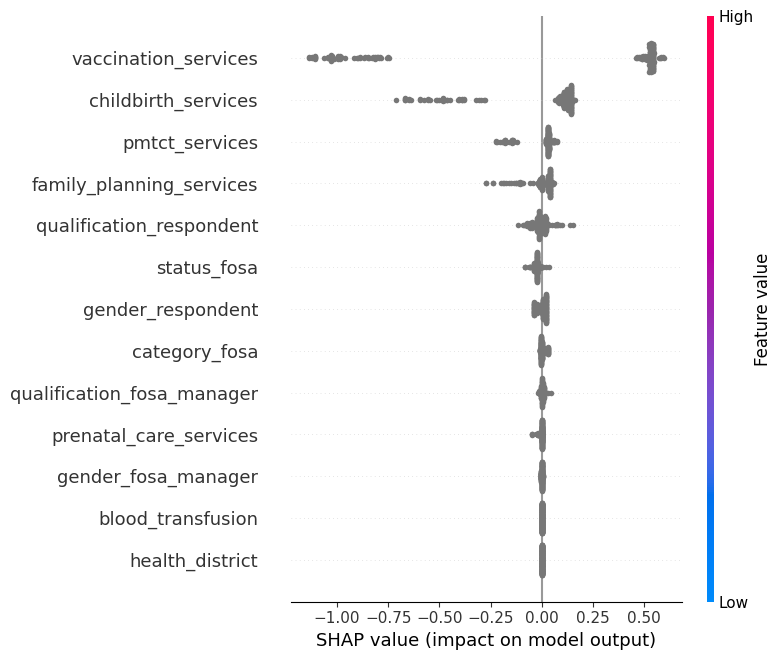

In [46]:
shap.summary_plot(
    shap_values,
    X,
    feature_names=X.columns,
    show=True
)


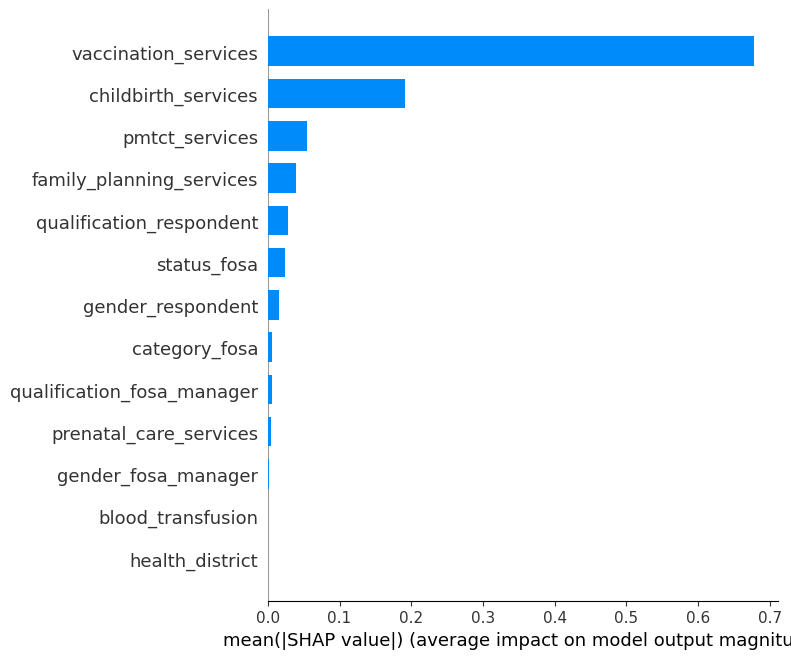

In [47]:
shap.summary_plot(
    shap_values,
    X,
    feature_names=X.columns,
    plot_type="bar",
    show=True
)


In [48]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=0
    )
    
    model.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )
    
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    auc_scores.append(auc)
    print(f"Fold {fold + 1}: AUC = {auc:.4f}")

Fold 1: AUC = 0.9155
Fold 2: AUC = 0.7633
Fold 3: AUC = 0.8551
Fold 4: AUC = 0.8019
Fold 5: AUC = 0.8186


In [55]:
FEATURE_COLUMNS = X.columns.tolist()
CAT_FEATURES = cat_features


In [56]:
import json

with open("feature_metadata.json", "w") as f:
    json.dump({
        "feature_columns": FEATURE_COLUMNS,
        "cat_features": CAT_FEATURES
    }, f)


In [54]:
model.save_model("catboost_operational_capacity.cbm")


In [49]:
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model_cv = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    )

    model_cv.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )

    y_proba = model_cv.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    auc_scores.append(auc)
    print(f"Fold {len(auc_scores)}: AUC = {auc:.4f}")

Fold 6: AUC = 0.9155
Fold 7: AUC = 0.7633
Fold 8: AUC = 0.8551
Fold 9: AUC = 0.8019
Fold 10: AUC = 0.8186


In [57]:
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model_cv = CatBoostClassifier(
        iterations=5000,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    )

    model_cv.fit(
        X_train, y_train,
        cat_features=cat_features,
        eval_set=(X_test, y_test),
        use_best_model=True,
        early_stopping_rounds=200
    )

    y_proba = model_cv.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    auc_scores.append(auc)
    print(f"Fold {fold}: AUC = {auc:.4f}")


AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [58]:
auc_scores = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model_cv = CatBoostClassifier(
        iterations=5000,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    )

    model_cv.fit(
        X_train, y_train,
        cat_features=cat_features,
        eval_set=(X_test, y_test),
        use_best_model=True,
        early_stopping_rounds=200
    )

    y_proba = model_cv.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    auc_scores.append(auc)
    print(f"Fold {fold}: AUC = {auc:.4f}")

print(f"Mean AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")


Fold 1: AUC = 0.9348
Fold 2: AUC = 0.8333
Fold 3: AUC = 0.9010
Fold 4: AUC = 0.8128
Fold 5: AUC = 0.9093
Mean AUC: 0.8782 ± 0.0469


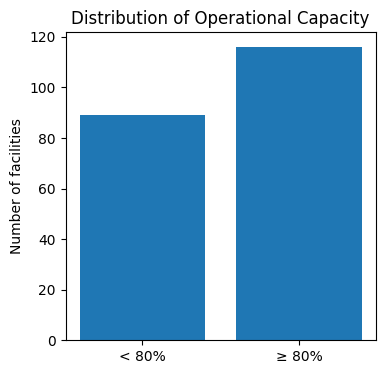

In [59]:
import matplotlib.pyplot as plt

counts = y.value_counts().sort_index()

plt.figure(figsize=(4,4))
plt.bar(
    ["< 80%", "≥ 80%"],
    counts,
)
plt.ylabel("Number of facilities")
plt.title("Distribution of Operational Capacity")
plt.show()


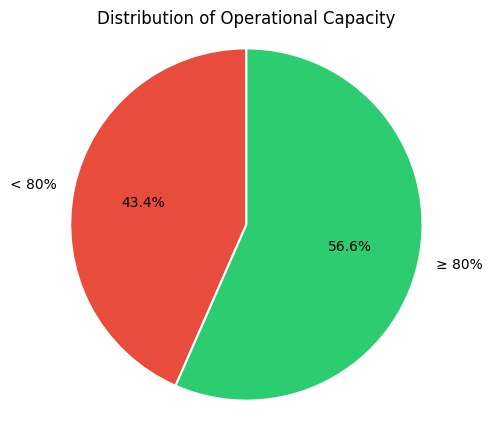

In [ ]:
import matplotlib.pyplot as plt

counts = y.value_counts().sort_index()
labels = ["< 80%", "≥ 80%"]
colors = ["#e74c3c", "#2ecc71"]  # red = low, green = high

plt.figure(figsize=(5,5))
plt.pie(
    counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
plt.title("Distribution of Operational Capacity", fontsize=12)
plt.axis("equal")  # ensures perfect circle
plt.show()


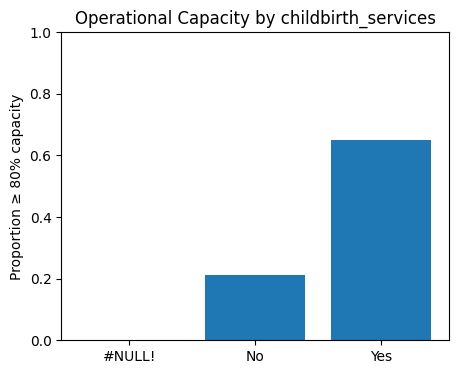

In [60]:
import pandas as pd

feature = "childbirth_services"  # change feature here

df_plot = (
    pd.concat([X[feature], y], axis=1)
      .groupby(feature)[y.name]
      .mean()
      .reset_index()
)

plt.figure(figsize=(5,4))
plt.bar(df_plot[feature], df_plot[y.name])
plt.ylim(0,1)
plt.ylabel("Proportion ≥ 80% capacity")
plt.title(f"Operational Capacity by {feature}")
plt.show()


In [72]:
for value in X[feature].unique():
    subset = X[X[feature] == value]

    counts = subset[y.name].value_counts().sort_index()

    plt.figure(figsize=(4,4))
    plt.pie(
        counts,
        labels=["< 80%", "≥ 80%"],
        autopct="%1.1f%%",
        startangle=90,
        colors=["#e74c3c", "#2ecc71"],
        wedgeprops={"edgecolor": "white", "linewidth": 1.2}
    )
    plt.title(f"Operational Capacity\nChildbirth services: {value}")
    plt.axis("equal")
    plt.show()


KeyError: 'y'

In [76]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   health_district             205 non-null    object
 1   category_fosa               205 non-null    object
 2   status_fosa                 205 non-null    object
 3   gender_fosa_manager         205 non-null    object
 4   qualification_fosa_manager  205 non-null    object
 5   qualification_respondent    205 non-null    object
 6   gender_respondent           205 non-null    object
 7   childbirth_services         205 non-null    object
 8   pmtct_services              205 non-null    object
 9   prenatal_care_services      205 non-null    object
 10  vaccination_services        205 non-null    object
 11  family_planning_services    205 non-null    object
 12  blood_transfusion           205 non-null    object
dtypes: object(13)
memory usage: 20.9+ KB


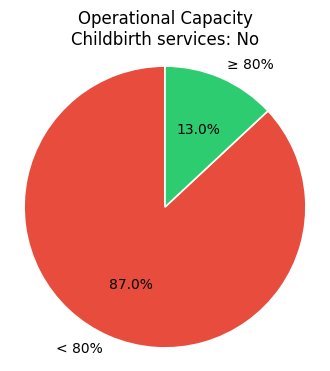

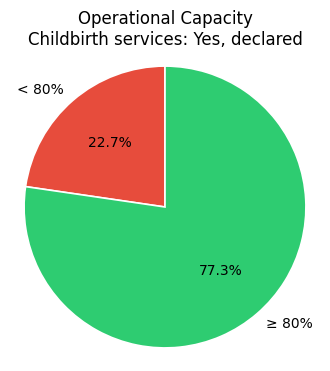

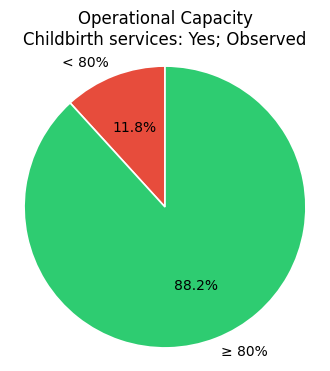

In [77]:
df_all = pd.concat([X, y.rename("target")], axis=1)
feature = "vaccination_services"  # change feature here

df_all = df_all[
    df_all[feature].notna() &
    (df_all[feature] != "#NULL!")
]
for value in df_all[feature].unique():
    subset = df_all[df_all[feature] == value]

    counts = subset["target"].value_counts().sort_index()

    plt.figure(figsize=(4,4))
    plt.pie(
        counts,
        labels=["< 80%", "≥ 80%"],
        autopct="%1.1f%%",
        startangle=90,
        colors=["#e74c3c", "#2ecc71"],
        wedgeprops={"edgecolor": "white", "linewidth": 1.2}
    )
    plt.title(f"Operational Capacity\nChildbirth services: {value}")
    plt.axis("equal")
    plt.show()


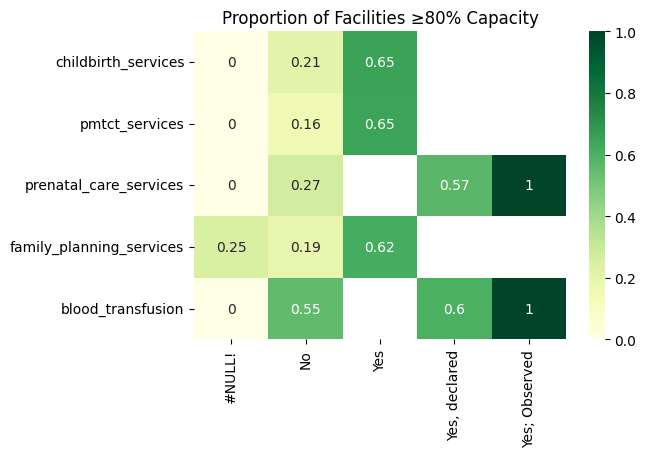

In [61]:
import seaborn as sns
import numpy as np

services = [
    "childbirth_services",
    "pmtct_services",
    "prenatal_care_services",
    "family_planning_services",
    "blood_transfusion"
]

heatmap_data = []

for s in services:
    prop = (
        pd.concat([X[s], y], axis=1)
          .groupby(s)[y.name]
          .mean()
    )
    heatmap_data.append(prop)

heatmap_df = pd.DataFrame(heatmap_data, index=services)

plt.figure(figsize=(6,4))
sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="YlGn",
    vmin=0, vmax=1
)
plt.title("Proportion of Facilities ≥80% Capacity")
plt.show()


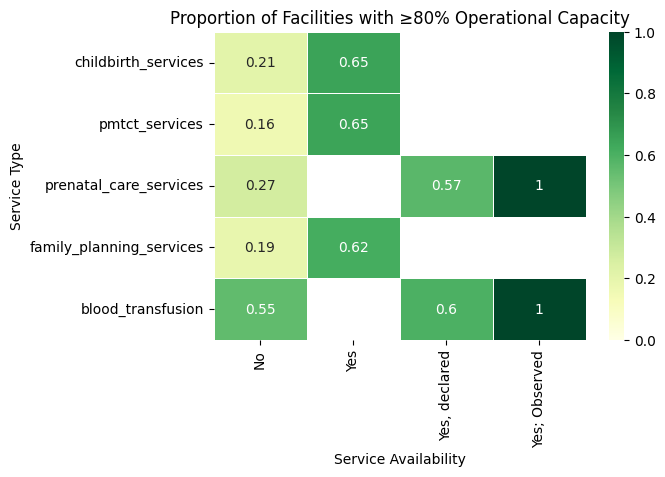

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

services = [
    "childbirth_services",
    "pmtct_services",
    "prenatal_care_services",
    "family_planning_services",
    "blood_transfusion"
]

# Combine X and y once
df_all = pd.concat([X, y.rename("target")], axis=1)

heatmap_data = []

for s in services:
    # Remove NULL / missing / placeholder values
    df_clean = df_all[
        df_all[s].notna() &
        (df_all[s] != "#NULL!")
    ]

    prop = (
        df_clean
        .groupby(s)["target"]
        .mean()
    )

    heatmap_data.append(prop)

# Create heatmap dataframe
heatmap_df = pd.DataFrame(heatmap_data, index=services)

plt.figure(figsize=(6,4))
sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="YlGn",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white"
)
plt.title("Proportion of Facilities with ≥80% Operational Capacity")
plt.xlabel("Service Availability")
plt.ylabel("Service Type")
plt.show()


In [62]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


NameError: name 'y_true' is not defined

In [63]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_oof = np.zeros(len(y))

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train = y.iloc[train_idx]

    model_cv = CatBoostClassifier(
        iterations=5000,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    )

    model_cv.fit(
        X_train, y_train,
        cat_features=CAT_FEATURES,
        eval_set=(X_test, y.iloc[test_idx]),
        early_stopping_rounds=200,
        use_best_model=True
    )

    y_oof[test_idx] = model_cv.predict_proba(X_test)[:, 1]


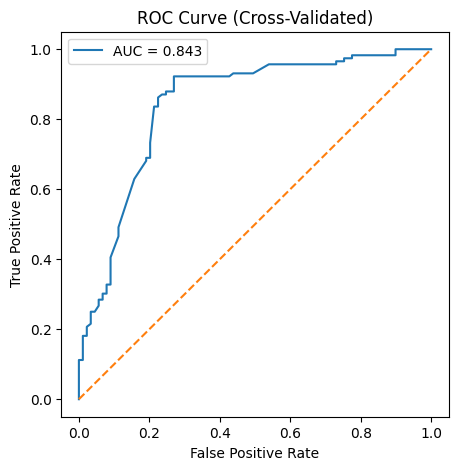

In [64]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y, y_oof)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Cross-Validated)")
plt.legend()
plt.show()


In [65]:
plt.figure(figsize=(5,4))
plt.hist(y_proba[y==0], bins=20, alpha=0.6, label="<80%")
plt.hist(y_proba[y==1], bins=20, alpha=0.6, label="≥80%")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Predicted Probability Distribution")
plt.legend()
plt.show()


IndexError: boolean index did not match indexed array along axis 0; size of axis is 41 but size of corresponding boolean axis is 205

<Figure size 500x400 with 0 Axes>

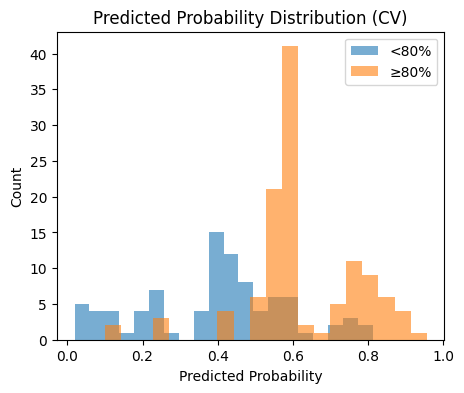

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.hist(y_oof[y == 0], bins=20, alpha=0.6, label="<80%")
plt.hist(y_oof[y == 1], bins=20, alpha=0.6, label="≥80%")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Predicted Probability Distribution (CV)")
plt.legend()
plt.show()


In [67]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y, y_proba, n_bins=10)

plt.figure(figsize=(5,5))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed proportion")
plt.title("Calibration Curve")
plt.show()


ValueError: Found input variables with inconsistent numbers of samples: [205, 41]

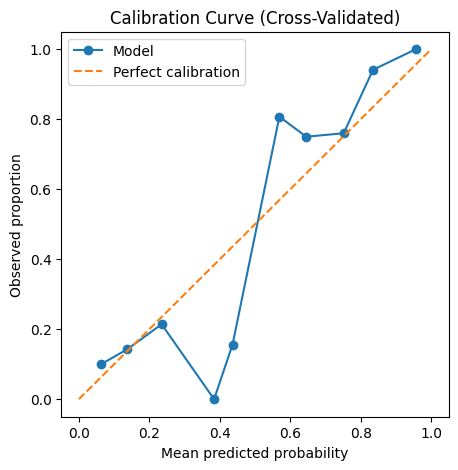

In [68]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y,
    y_oof,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(5,5))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed proportion")
plt.title("Calibration Curve (Cross-Validated)")
plt.legend()
plt.show()


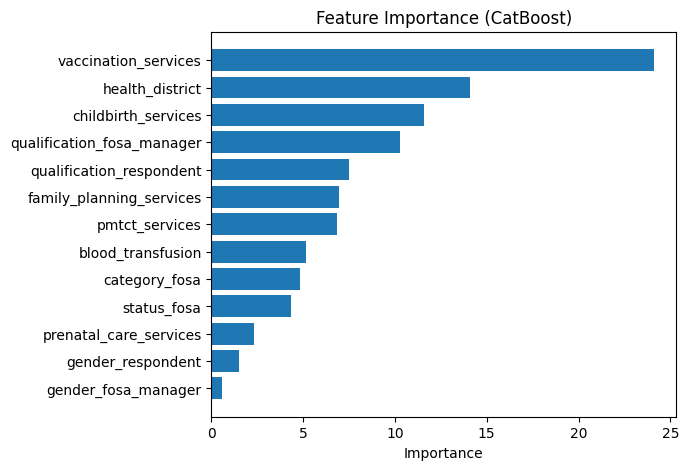

In [69]:
importances = model.get_feature_importance()
features = X.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(6,5))
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.title("Feature Importance (CatBoost)")
plt.xlabel("Importance")
plt.show()


In [50]:
import numpy as np
from scipy import stats

auc_scores = np.array(auc_scores)

mean_auc = auc_scores.mean()
std_auc = auc_scores.std(ddof=1)

ci_low, ci_high = stats.t.interval(
    0.95,
    df=len(auc_scores)-1,
    loc=mean_auc,
    scale=std_auc / np.sqrt(len(auc_scores))
)

print(f"Mean AUC: {mean_auc:.3f}")
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")


Mean AUC: 0.831
95% CI: [0.792, 0.870]


In [51]:
rng = np.random.default_rng(42)
boot_means = []

for _ in range(2000):
    sample = rng.choice(auc_scores, size=len(auc_scores), replace=True)
    boot_means.append(sample.mean())

ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f"95% Bootstrap CI: [{ci_low:.3f}, {ci_high:.3f}]")

95% Bootstrap CI: [0.799, 0.863]


In [53]:
import json

metadata = {
    "features": cat_features,
    "target": "y",
    "model": "CatBoostClassifier",
    "missing_value_strategy": "Missing category",
    "outcome_definition": "Operational Capacity >= 80"
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)


In [2]:
# ============================================================
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import re   
import os
import pathlib


# ============================================================
# 2. LOAD DATA
# ============================================================

DATA_PATH = r"C:/Users/Gilles/Documents/Master_thesis/Tedjo Octavia/Tedjo Octavia/Octavia_data_base.xlsx"  
df = pd.read_excel(DATA_PATH)

# Strip leading/trailing spaces from column names to avoid KeyError
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)

# ============================================================
# 3. DEFINE OUTCOME (BINARY)
# ============================================================

# If Operational Capacity already exists as >=80 / <80:
df["y"] = (
    df["Operational Capacity"]
    .astype(str)
    .str.replace("\u2265", ">=", regex=False)  # replace ≥ with >=
    .str.replace(" ", "", regex=False)         # remove spaces
    .str.contains(r">=80", regex=True)
    .astype(int)
)



# If numeric score exists (recommended)
#df["y"] = (df["SCOREGLOBALDELAFOSA"] >= 80).astype(int)

print(df["y"].value_counts())

# ============================================================
# 4. DROP IDENTIFIERS & LEAKAGE VARIABLES
# ============================================================

DROP_COLS = [
    "Time clock",
    "Questionnaire code",
    "Name of the FOSA",
    "Telephone contact of the FOSA manager",
    "Telephone contact of the respondent",
    "SCOREGLOBALDELAFOSA",
    "FOSAOPERATIONAL"
]

df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================

# Replace special missing values
df = df.replace(["#NULL!", "NULL", "None"], np.nan)

# Separate X and y
X = df.drop(columns=["y"])
y = df["y"]

# ============================================================
# 6. IDENTIFY FEATURE TYPES
# ============================================================

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:", len(categorical_cols))
print("Numerical features:", len(numerical_cols))

# ============================================================
# 7. PREPROCESSING PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_cols
        ),
        ("num", "passthrough", numerical_cols)
    ]
)


# ============================================================
# 8. MODEL
# ============================================================

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ]
)

# ============================================================
# 9. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# ============================================================
# 10. TRAIN MODEL
# ============================================================

pipeline.fit(X_train, y_train)

# ============================================================
# 11. EVALUATION
# ============================================================

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.title("Confusion Matrix")
plt.show()

# ============================================================
# 12. SHAP EXPLAINABILITY
# ============================================================

# Extract transformed feature names
ohe = pipeline.named_steps["preprocess"].named_transformers_["cat"]
ohe_features = ohe.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([ohe_features, numerical_cols])

# Transform data
X_train_transformed = pipeline.named_steps["preprocess"].transform(X_train)

explainer = shap.TreeExplainer(pipeline.named_steps["model"])
shap_values = explainer.shap_values(X_train_transformed)

# ============================================================
# 13. SHAP SUMMARY PLOT (GLOBAL IMPORTANCE)
# ============================================================

shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    show=True
)

# ============================================================
# 14. SHAP BAR PLOT (GLOBAL)
# ============================================================

shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

# ============================================================
# 15. LOCAL EXPLANATION (SINGLE FACILITY)
# ============================================================

idx = 0  # change index
shap.force_plot(
    explainer.expected_value,
    shap_values[idx, :],
    X_train_transformed[idx, :],
    feature_names=feature_names,
    matplotlib=True
)


C:\Users\Gilles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset shape: (205, 272)
y
1    116
0     89
Name: count, dtype: int64
Categorical features: 239
Numerical features: 30


C:\Users\Gilles\AppData\Local\Temp\ipykernel_9380\3068922330.py:82: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(["#NULL!", "NULL", "None"], np.nan)


TypeError: Encoders require their input argument must be uniformly strings or numbers. Got ['float', 'str']

In [4]:
!pip install pandas numpy scikit-learn shap xgboost matplotlib seaborn


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 10.5 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.1 MB 9.9 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 9.6 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 9.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   ---------------------------------------- 548.0/548.0 kB 6.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   - -------------------------------------- 1.8/72.0 MB 9.1 MB/s eta 0:00:08
   -- ------------------------------------- 3.9/72.0 MB 9.8 MB/s eta 0:00:07
   --- ------------------------------------ 5.8/72.0 MB 9.8 MB/s eta 0:00:07
   ---- ----------------------------------- 7.6/72.0 MB 9.8 MB/s eta 0:00:07
   ----- ------------


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\Gilles\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
